Running 15 parallel iterations with K=2000 episodes each...
This may take several minutes...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running experiment...
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Experiment complete.
Computing optimal value V*(x0) via Monte Carlo...


[Parallel(n_jobs=-1)]: Done  15 out of  15 | elapsed:  3.4min finished


  Best constant allocation: 1.000 (per asset: 0.5000), V* = 16.9960
Estimated V*(x0) = 16.9960


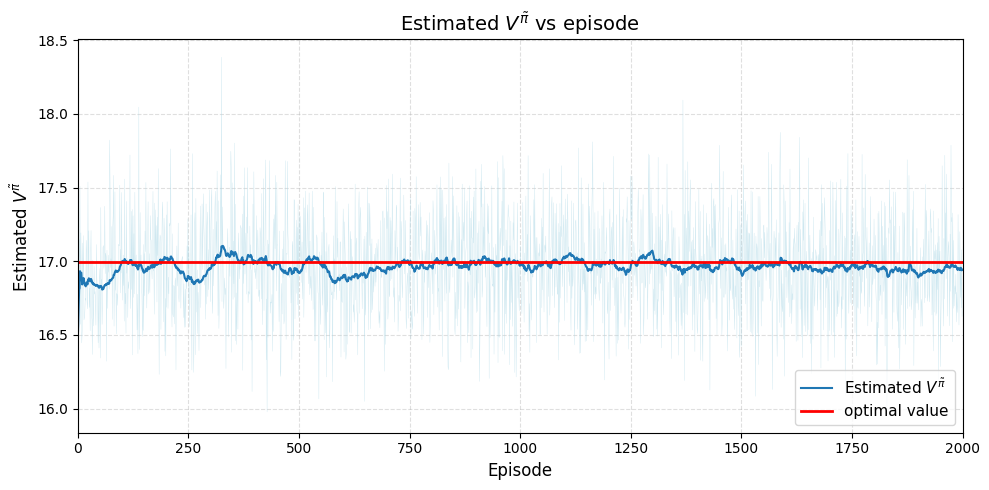

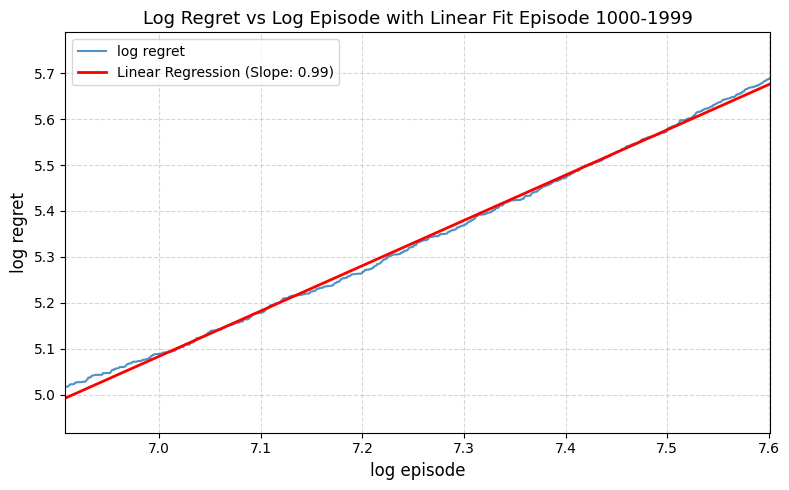


Regret order estimation:
  Slope = 0.9859
  R^2 = 0.9983
  This suggests cumulative regret ~ K^0.99

SUMMARY
  Episodes (K):            2000
  Horizon (H):             30
  Parallel runs:           15
  Starting state (X1):     2
  Optimal V*(x0):          16.9960
  Final avg reward (last 100): 16.9396
  Total cumulative regret: 295.53
  Regret slope:            0.9859


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from scipy import stats
import importlib
import aaro_draft as ad
importlib.reload(ad)

# =============================================================================
# 1. Run the Experiment
# =============================================================================
n_runs = 15

print(f"Running {n_runs} parallel iterations with K={ad.nEps} episodes each...")
print("This may take several minutes...")

list_of_vpi = Parallel(n_jobs=-1, verbose=5)(
    delayed(ad.run_single_experiment_iteration)(i) for i in range(n_runs)
)

vpi_df = pd.DataFrame(list_of_vpi).T
vpi_estimate = vpi_df.mean(axis=1)

# =============================================================================
# 2. Compute Optimal Value V*(x0)
# =============================================================================
print("Computing optimal value V*(x0) via Monte Carlo...")
optimal_value = ad.compute_optimal_value(ad.starting_state, ad.epLen, ad.Delta)
print(f"Estimated V*(x0) = {optimal_value:.4f}")

# =============================================================================
# 3. Plot (a): Estimated V^π vs Episode
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 5))
episodes = np.arange(len(vpi_estimate))

ax.plot(episodes, vpi_estimate,
        color='lightblue', linewidth=0.3, alpha=0.6)

window = 50
smoothed = vpi_estimate.rolling(window=window, min_periods=1).mean()
ax.plot(episodes, smoothed, color='tab:blue', linewidth=1.5,
        label=r'Estimated $V^{\tilde{\pi}}$')

ax.axhline(y=optimal_value, color='red', linewidth=2, label='optimal value')

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel(r'Estimated $V^{\tilde{\pi}}$', fontsize=12)
ax.set_title(r'Estimated $V^{\tilde{\pi}}$ vs episode', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xlim([0, ad.nEps])

plt.tight_layout()
plt.savefig('vpi_vs_episode.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 4. Plot (b): Log Regret vs Log Episode with Linear Fit
# =============================================================================
instantaneous_regret = np.maximum(optimal_value - vpi_estimate.values, 0)
cumulative_regret = np.cumsum(instantaneous_regret)

episodes_1idx = np.arange(1, len(cumulative_regret) + 1)

valid_mask = cumulative_regret > 0
log_episodes = np.log(episodes_1idx[valid_mask])
log_regret = np.log(cumulative_regret[valid_mask])

fit_start = 1000
fit_end = ad.nEps
fit_mask = ((episodes_1idx[valid_mask] >= fit_start) &
            (episodes_1idx[valid_mask] <= fit_end))

if np.sum(fit_mask) > 10:
    log_eps_fit = log_episodes[fit_mask]
    log_reg_fit = log_regret[fit_mask]

    slope, intercept, r_value, p_value, std_err = stats.linregress(
        log_eps_fit, log_reg_fit
    )
    fit_line = slope * log_eps_fit + intercept

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(log_episodes[fit_mask], log_regret[fit_mask],
            color='tab:blue', linewidth=1.5, alpha=0.8, label='log regret')
    ax.plot(log_eps_fit, fit_line,
            color='red', linewidth=2,
            label=f'Linear Regression (Slope: {slope:.2f})')

    y_min = log_reg_fit.min() - 0.1
    y_max = log_reg_fit.max() + 0.1
    ax.set_xlim([np.log(fit_start), np.log(fit_end)])
    ax.set_ylim([y_min, y_max])

    ax.set_xlabel('log episode', fontsize=12)
    ax.set_ylabel('log regret', fontsize=12)
    ax.set_title(
        f'Log Regret vs Log Episode with Linear Fit Episode {fit_start}-{fit_end-1}',
        fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig('log_regret_vs_log_episode.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nRegret order estimation:")
    print(f"  Slope = {slope:.4f}")
    print(f"  R^2 = {r_value**2:.4f}")
    print(f"  This suggests cumulative regret ~ K^{slope:.2f}")
else:
    print("Not enough valid data points for linear regression.")

# =============================================================================
# 5. Summary
# =============================================================================
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"  Episodes (K):            {ad.nEps}")
print(f"  Horizon (H):             {ad.epLen}")
print(f"  Parallel runs:           {n_runs}")
print(f"  Starting state (X1):     {ad.starting_state}")
print(f"  Optimal V*(x0):          {optimal_value:.4f}")
print(f"  Final avg reward (last 100): {vpi_estimate.iloc[-100:].mean():.4f}")
print(f"  Total cumulative regret: {cumulative_regret[-1]:.2f}")
if np.sum(fit_mask) > 10:
    print(f"  Regret slope:            {slope:.4f}")
print("=" * 60)

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from scipy import stats
import importlib

import aaro_draft as ad
from aaro_bellman import BellmanSolver

importlib.reload(ad)

# =============================================================================
# 1. SOLVE BELLMAN EQUATION
# =============================================================================
solver = BellmanSolver(
    theta=ad.theta,
    kappa=ad.kappa,
    sigma=ad.sigma,
    Delta=ad.Delta,
    rho=ad.rho,
    epLen=ad.epLen,
    action_dim=ad.action_dim,
    initial_q=ad.initial_q,
    n_state_grid=401,
    n_action_per_dim=21,
    n_quadrature=64
)

solver.solve(verbose=True)

v_star = solver.get_value(ad.starting_state, 0)
print(f"\nBellman V*(x0={ad.starting_state}) = {v_star:.6f}")

# Verify via simulation
v_sim, v_se, _ = solver.simulate_optimal_policy(ad.starting_state, n_sims=100000)
print(f"Simulated V*(x0) = {v_sim:.4f} ± {v_se:.4f}")

# =============================================================================
# 2. BELLMAN SOLVER ANALYSIS PLOTS
# =============================================================================
print("\nGenerating Bellman analysis plots...")

solver.plot_value_functions()
solver.plot_value_function_zoomed(x_range=(0, 6))
solver.plot_optimal_policy()
solver.plot_policy_heatmap()
solver.plot_trajectory_distribution(x0=ad.starting_state)

# =============================================================================
# 3. RUN THE RL AGENT
# =============================================================================
n_runs = 50

print(f"\nRunning {n_runs} RL iterations with K={ad.nEps} episodes...")

list_of_vpi = Parallel(n_jobs=-1, verbose=5)(
    delayed(ad.run_single_experiment_iteration)(i) for i in range(n_runs)
)

vpi_df = pd.DataFrame(list_of_vpi).T
vpi_estimate = vpi_df.mean(axis=1)

# =============================================================================
# 4. PLOT (a): V^π vs Episode with Bellman V* Line
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 5))
episodes = np.arange(len(vpi_estimate))

ax.plot(episodes, vpi_estimate,
        color='lightblue', linewidth=0.3, alpha=0.5)

window = 50
smoothed = vpi_estimate.rolling(window=window, min_periods=1).mean()
ax.plot(episodes, smoothed, color='tab:blue', linewidth=1.5,
        label=r'RL Agent $V^{\tilde{\pi}}$ (smoothed)')

ax.axhline(y=v_star, color='red', linewidth=2,
           label=f'Bellman V* = {v_star:.2f}')

# Also show MC V* for comparison
ax.axhline(y=v_sim, color='orange', linewidth=1.5, linestyle='--',
           label=f'MC V* = {v_sim:.2f}', alpha=0.7)

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel(r'Estimated $V^{\tilde{\pi}}$', fontsize=12)
ax.set_title(r'Estimated $V^{\tilde{\pi}}$ vs Episode (Bellman Ground Truth)',
             fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xlim([0, ad.nEps])
plt.tight_layout()
plt.savefig('comparison_vpi_vs_episode.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 5. PLOT (b): Log Regret vs Log Episode (using exact Bellman V*)
# =============================================================================
instantaneous_regret = np.maximum(v_star - vpi_estimate.values, 0)
cumulative_regret = np.cumsum(instantaneous_regret)

episodes_1idx = np.arange(1, len(cumulative_regret) + 1)
valid_mask = cumulative_regret > 0
log_episodes = np.log(episodes_1idx[valid_mask])
log_regret = np.log(cumulative_regret[valid_mask])

fit_start = 1000
fit_end = ad.nEps
fit_mask = ((episodes_1idx[valid_mask] >= fit_start) &
            (episodes_1idx[valid_mask] <= fit_end))

if np.sum(fit_mask) > 10:
    log_eps_fit = log_episodes[fit_mask]
    log_reg_fit = log_regret[fit_mask]

    slope, intercept, r_value, _, _ = stats.linregress(
        log_eps_fit, log_reg_fit
    )
    fit_line = slope * log_eps_fit + intercept

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(log_episodes[fit_mask], log_regret[fit_mask],
            color='tab:blue', linewidth=1.5, alpha=0.8, label='log regret')
    ax.plot(log_eps_fit, fit_line, color='red', linewidth=2,
            label=f'Linear Regression (Slope: {slope:.2f})')

    ax.set_xlim([np.log(fit_start), np.log(fit_end)])
    y_pad = 0.15 * (log_reg_fit.max() - log_reg_fit.min())
    ax.set_ylim([log_reg_fit.min() - y_pad, log_reg_fit.max() + y_pad])

    ax.set_xlabel('log episode', fontsize=12)
    ax.set_ylabel('log regret', fontsize=12)
    ax.set_title(
        f'Log Regret vs Log Episode (Bellman V*) Fit {fit_start}-{fit_end-1}',
        fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('comparison_log_regret.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nRegret slope = {slope:.4f}, R² = {r_value**2:.4f}")
    print(f"Cumulative regret ~ K^{slope:.2f}")

# =============================================================================
# 6. CONVERGENCE GAP ANALYSIS
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: gap V* - V^π over time
ax = axes[0]
gap = v_star - smoothed
ax.plot(episodes, gap, color='tab:red', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
ax.fill_between(episodes, 0, gap, alpha=0.2, color='red')
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel(r'$V^* - V^{\tilde{\pi}}$', fontsize=12)
ax.set_title('Optimality Gap Over Training', fontsize=13)
ax.grid(True, linestyle='--', alpha=0.4)

# Right: % of V* captured
ax = axes[1]
pct_captured = (smoothed / v_star) * 100
ax.plot(episodes, pct_captured, color='tab:green', linewidth=1.5)
ax.axhline(y=100, color='red', linestyle='--', alpha=0.5, label='100% (V*)')
ax.axhline(y=95, color='orange', linestyle=':', alpha=0.5, label='95%')
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('% of V* captured', fontsize=12)
ax.set_title('Learning Progress (% of Optimal)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_ylim([max(0, pct_captured.min() - 5), 105])

plt.tight_layout()
plt.savefig('comparison_convergence_gap.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 7. SUMMARY TABLE
# =============================================================================
final_100_avg = vpi_estimate.iloc[-100:].mean()
final_100_std = vpi_estimate.iloc[-100:].std()

print("\n" + "=" * 65)
print("COMPLETE COMPARISON SUMMARY")
print("=" * 65)
print(f"  Bellman V*(x0=2):           {v_star:.4f}")
print(f"  MC Verification V*:         {v_sim:.4f} ± {v_se:.4f}")
print(f"  RL Final Avg (last 100):    {final_100_avg:.4f} ± {final_100_std:.4f}")
print(f"  Optimality Gap:             {v_star - final_100_avg:.4f}")
print(f"  % of V* achieved:           {100*final_100_avg/v_star:.1f}%")
print(f"  Cumulative Regret:          {cumulative_regret[-1]:.1f}")
if np.sum(fit_mask) > 10:
    print(f"  Regret Growth Order:        K^{slope:.2f}")
print(f"  Total Episodes (K):         {ad.nEps}")
print(f"  Horizon (H):                {ad.epLen}")
print(f"  Parallel Runs:              {n_runs}")
print("=" * 65)